# Chapter 8 Companion — Advanced Topics

Runnable companions to the worked examples in
[`docs/08_advanced_topics`](../docs/08_advanced_topics):

- [`03_many_body_physics_and_simulation.md`](../docs/08_advanced_topics/03_many_body_physics_and_simulation.md)
- [`02_quantum_information_theory.md`](../docs/08_advanced_topics/02_quantum_information_theory.md)

In [1]:
%matplotlib inline
import numpy as np
import matplotlib.pyplot as plt
from scipy.linalg import expm

np.set_printoptions(precision=6, suppress=True)

I2 = np.eye(2, dtype=complex)
X = np.array([[0, 1], [1, 0]], dtype=complex)
Z = np.array([[1, 0], [0, -1]], dtype=complex)

def kron(*ops):
    out = np.array([[1]], dtype=complex)
    for o in ops:
        out = np.kron(out, o)
    return out

def op_on(single, i, n):
    return kron(*[single if k == i else I2 for k in range(n)])

## Example 1 — Exact 2-site TFIM: `E₀ = −√5`

*Docs: `03_many_body_physics_and_simulation.md`, Exercise 1.* For
`H = −J Z₁Z₂ − h(X₁+X₂)` at `J = h = 1`, the docs diagonalize the symmetric 3×3 block and
find `E₀ = −√5 ≈ −2.236`, matching the closed form `−√(J² + 4h²)`; the antisymmetric state
`(|01⟩−|10⟩)/√2` decouples with energy `+J`.

In [2]:
J = h = 1.0
H2 = -J * kron(Z, Z) - h * (kron(X, I2) + kron(I2, X))
evals, evecs = np.linalg.eigh(H2)
print("spectrum:", evals)
print(f"E0 = {evals[0]:.6f}  vs  -sqrt(5) = {-np.sqrt(5):.6f}  and  -sqrt(J²+4h²) = {-np.sqrt(J**2+4*h**2):.6f}")
assert np.isclose(evals[0], -np.sqrt(5))

# antisymmetric state is an eigenstate with energy +J
anti = np.zeros(4, dtype=complex); anti[0b01], anti[0b10] = 1/np.sqrt(2), -1/np.sqrt(2)
print("H|anti> = +J|anti>:", np.allclose(H2 @ anti, J * anti))
assert np.allclose(H2 @ anti, J * anti)

# sanity limits from the docs: E0 -> -J at h=0, -2h at J=0; interacting value beats both
for JJ, hh, expected in [(1, 0, -1), (0, 1, -2)]:
    Hlim = -JJ*kron(Z, Z) - hh*(kron(X, I2) + kron(I2, X))
    print(f"J={JJ}, h={hh}: E0 = {np.linalg.eigvalsh(Hlim)[0]:.3f} (docs: {expected})")
    assert np.isclose(np.linalg.eigvalsh(Hlim)[0], expected)

spectrum: [-2.236068 -1.        1.        2.236068]
E0 = -2.236068  vs  -sqrt(5) = -2.236068  and  -sqrt(J²+4h²) = -2.236068
H|anti> = +J|anti>: True
J=1, h=0: E0 = -1.000 (docs: -1)
J=0, h=1: E0 = -2.000 (docs: -2)


## Example 2 — First-order Trotter error scaling for the 4-site TFIM

*Docs: `03_many_body_physics_and_simulation.md`, "Worked Example: Trotter Circuit for 4-Site
Ising Model".* `H = H_ZZ + H_X` with `H_ZZ = −J(Z₁Z₂+Z₂Z₃+Z₃Z₄)`, `H_X = −h ΣXᵢ`. The
first-order Lie–Trotter product `(e^{−iH_X t/n} e^{−iH_ZZ t/n})ⁿ` has total error
`≤ t² ‖[H_ZZ, H_X]‖ / (2n)` — an `O(1/n)` decay we verify numerically, along with the docs'
loose bound arithmetic (`‖[H_ZZ,H_X]‖ ≤ 24Jh`, so `ε = 0.01` needs `n ≥ 1200` and 7200 CNOTs).

||[H_ZZ, H_X]|| = 8.944   (docs' loose bound: 2·||H_ZZ||·||H_X|| ≤ 24Jh = 24)
n =    1: 1st-order error = 1.85e+00 (bound 4.47e+00),  2nd-order = 1.53e+00
n =    2: 1st-order error = 7.73e-01 (bound 2.24e+00),  2nd-order = 3.17e-01
n =    4: 1st-order error = 3.56e-01 (bound 1.12e+00),  2nd-order = 7.30e-02
n =    8: 1st-order error = 1.74e-01 (bound 5.59e-01),  2nd-order = 1.79e-02
n =   16: 1st-order error = 8.65e-02 (bound 2.80e-01),  2nd-order = 4.45e-03
n =   32: 1st-order error = 4.32e-02 (bound 1.40e-01),  2nd-order = 1.11e-03
n =   64: 1st-order error = 2.16e-02 (bound 6.99e-02),  2nd-order = 2.78e-04
n =  128: 1st-order error = 1.08e-02 (bound 3.49e-02),  2nd-order = 6.94e-05
n =  256: 1st-order error = 5.40e-03 (bound 1.75e-02),  2nd-order = 1.74e-05

fitted scaling: 1st order ~ n^-1.00 (theory -1), 2nd order ~ n^-2.00 (theory -2)


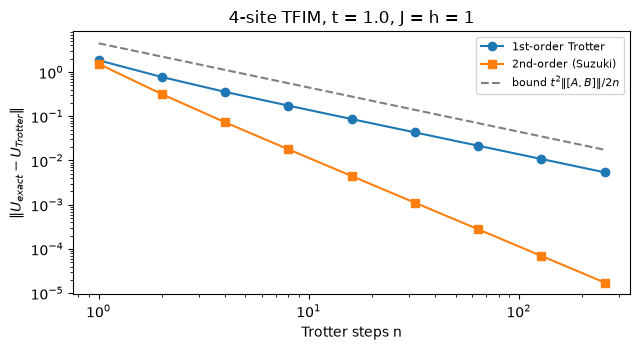

docs bound arithmetic: eps = 0.01 -> n >= 1200 steps, 7200 CNOTs (docs: 1200 steps, 7200 CNOTs)
actual commutator gives the much smaller n ≈ 448 — the bound is loose, the scaling is what matters.


In [3]:
n_sites = 4
J = h = t = 1.0
H_ZZ = -J * sum(op_on(Z, i, n_sites) @ op_on(Z, i+1, n_sites) for i in range(n_sites-1))
H_X  = -h * sum(op_on(X, i, n_sites) for i in range(n_sites))
H = H_ZZ + H_X

U_exact = expm(-1j * H * t)
UX = lambda dt: expm(-1j * H_X * dt)
UZZ = lambda dt: expm(-1j * H_ZZ * dt)

def trotter1_error(n_steps):
    step = UX(t/n_steps) @ UZZ(t/n_steps)
    return np.linalg.norm(np.linalg.matrix_power(step, n_steps) - U_exact, 2)

def trotter2_error(n_steps):
    dt = t / n_steps
    step = UZZ(dt/2) @ UX(dt) @ UZZ(dt/2)
    return np.linalg.norm(np.linalg.matrix_power(step, n_steps) - U_exact, 2)

comm_norm = np.linalg.norm(H_ZZ @ H_X - H_X @ H_ZZ, 2)
print(f"||[H_ZZ, H_X]|| = {comm_norm:.3f}   (docs' loose bound: 2·||H_ZZ||·||H_X|| ≤ 24Jh = 24)")
assert comm_norm <= 24

ns = np.array([1, 2, 4, 8, 16, 32, 64, 128, 256])
err1 = np.array([trotter1_error(n) for n in ns])
err2 = np.array([trotter2_error(n) for n in ns])
bound = t**2 * comm_norm / (2 * ns)
for n, e1, e2, b in zip(ns, err1, err2, bound):
    print(f"n = {n:4d}: 1st-order error = {e1:.2e} (bound {b:.2e}),  2nd-order = {e2:.2e}")
assert np.all(err1 <= bound + 1e-9)                 # the rigorous bound holds

# scaling exponents from the last decade of points
slope1 = np.polyfit(np.log(ns[-4:]), np.log(err1[-4:]), 1)[0]
slope2 = np.polyfit(np.log(ns[-4:]), np.log(err2[-4:]), 1)[0]
print(f"\nfitted scaling: 1st order ~ n^{slope1:.2f} (theory -1), 2nd order ~ n^{slope2:.2f} (theory -2)")
assert abs(slope1 + 1) < 0.1 and abs(slope2 + 2) < 0.1

fig, ax = plt.subplots(figsize=(6.5, 3.6))
ax.loglog(ns, err1, "o-", label="1st-order Trotter")
ax.loglog(ns, err2, "s-", label="2nd-order (Suzuki)")
ax.loglog(ns, bound, "--", color="gray", label=r"bound $t^2\|[A,B]\|/2n$")
ax.set_xlabel("Trotter steps n"); ax.set_ylabel(r"$\|U_{exact} - U_{Trotter}\|$")
ax.set_title(f"4-site TFIM, t = {t}, J = h = 1")
ax.legend(fontsize=8); fig.tight_layout(); plt.show()

# docs' worst-case budget arithmetic
n_req = int(t**2 * 24 / (2 * 0.01))
print(f"docs bound arithmetic: eps = 0.01 -> n >= {n_req} steps, "
      f"{n_req * 6} CNOTs (docs: 1200 steps, 7200 CNOTs)")
assert n_req == 1200
print(f"actual commutator gives the much smaller n ≈ {int(np.ceil(t**2*comm_norm/(2*0.01)))} "
      "— the bound is loose, the scaling is what matters.")

## Example 3 — Entanglement entropy of Bell and partially-entangled states

*Docs: `02_quantum_information_theory.md`, "Worked Example".* Reduced-state entropies:

- Bell state `|Φ⁺⟩`: `ρ_A = I/2`, `S = 1` ebit (maximal for a qubit pair);
- product state `|00⟩`: `S = 0`;
- `√0.9|00⟩ + √0.1|11⟩`: `S = H₂(0.9) ≈ 0.469` ebit.

|Φ+> = (|00>+|11>)/√2      S(ρ_A) = 1.000 ebit  (docs: 1.0)
|00> (product)             S(ρ_A) = -0.000 ebit  (docs: 0.0)
√0.9|00> + √0.1|11>        S(ρ_A) = 0.469 ebit  (docs: 0.469)


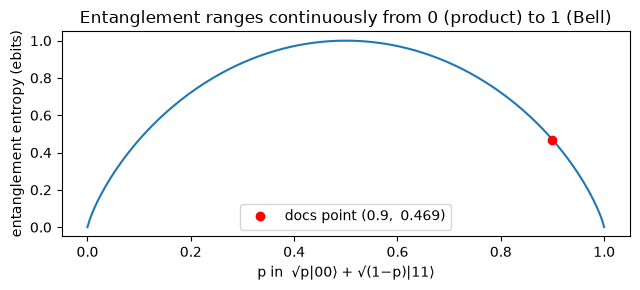

In [4]:
def reduced_A(psi4):
    rho = np.outer(psi4, psi4.conj()).reshape(2, 2, 2, 2)
    return np.einsum("ajbj->ab", rho)

def entropy_bits(rho):
    lam = np.linalg.eigvalsh(rho)
    lam = lam[lam > 1e-12]
    return float(-np.sum(lam * np.log2(lam)))

states = {
    "|Φ+> = (|00>+|11>)/√2": np.array([1, 0, 0, 1]) / np.sqrt(2),
    "|00> (product)":         np.array([1, 0, 0, 0], dtype=float),
    "√0.9|00> + √0.1|11>":    np.array([np.sqrt(0.9), 0, 0, np.sqrt(0.1)]),
}
expected = [1.0, 0.0, 0.469]
for (name, psi), ex in zip(states.items(), expected):
    S = entropy_bits(reduced_A(psi))
    print(f"{name:26s} S(ρ_A) = {S:.3f} ebit  (docs: {ex})")
    assert np.isclose(S, ex, atol=1e-3)

# entanglement entropy across the family √p|00> + √(1-p)|11> is the binary entropy
ps = np.linspace(0, 1, 200)
Ss = [entropy_bits(reduced_A(np.array([np.sqrt(p), 0, 0, np.sqrt(1-p)]))) for p in ps]
fig, ax = plt.subplots(figsize=(6.5, 3))
ax.plot(ps, Ss)
ax.plot([0.9], [0.469], "ro", label=r"docs point $(0.9,\ 0.469)$")
ax.set_xlabel("p in  √p|00⟩ + √(1−p)|11⟩"); ax.set_ylabel("entanglement entropy (ebits)")
ax.set_title("Entanglement ranges continuously from 0 (product) to 1 (Bell)")
ax.legend(); fig.tight_layout(); plt.show()

## Example 4 — Negative conditional entropy and the Holevo bound

*Docs: `02_quantum_information_theory.md`, Exercises 1–2.*

- Classically correlated `ρ = (|00⟩⟨00| + |11⟩⟨11|)/2`: `S(A|B) = S(AB) − S(B) = 1 − 1 = 0`.
- Bell state: `S(A|B) = 0 − 1 = **−1**` — impossible classically.
- Alice sends `|0⟩` or `|+⟩` with probability ½ each: the Holevo bound is
  `χ = S(ρ̄) ≈ 0.601` bits — a full classical bit cannot be recovered from non-orthogonal
  signal states.

In [5]:
def entropy_matrix(rho):
    lam = np.linalg.eigvalsh(rho)
    lam = lam[lam > 1e-12]
    return float(-np.sum(lam * np.log2(lam)))

# (a) classically correlated state
rho_cc = np.zeros((4, 4)); rho_cc[0, 0] = rho_cc[3, 3] = 0.5
rho_B = rho_cc.reshape(2,2,2,2); rho_B = np.einsum("iaib->ab", rho_B)
S_AB, S_B = entropy_matrix(rho_cc), entropy_matrix(rho_B)
print(f"classical correlation: S(AB) = {S_AB:.3f}, S(B) = {S_B:.3f}, S(A|B) = {S_AB - S_B:.3f} (docs: 0)")
assert np.isclose(S_AB - S_B, 0)

# (b) Bell state
bell = np.array([1, 0, 0, 1]) / np.sqrt(2)
rho_bell = np.outer(bell, bell)
rho_B2 = np.einsum("iaib->ab", rho_bell.reshape(2,2,2,2))
S_AB2, S_B2 = entropy_matrix(rho_bell), entropy_matrix(rho_B2)
print(f"Bell state:            S(AB) = {S_AB2:.3f}, S(B) = {S_B2:.3f}, S(A|B) = {S_AB2 - S_B2:.3f} (docs: -1)")
assert np.isclose(S_AB2 - S_B2, -1)
print("  -> negative conditional entropy: the joint state is perfectly known while each")
print("     part alone is maximally uncertain — impossible classically.\n")

# (c) Holevo bound for {|0>, |+>} with p = 1/2 each
ket0 = np.array([1, 0], dtype=float)
ketp = np.array([1, 1]) / np.sqrt(2)
rho_bar = 0.5 * np.outer(ket0, ket0) + 0.5 * np.outer(ketp, ketp)
print("ρ̄ =\n", rho_bar, " (docs: [[3/4, 1/4],[1/4, 1/4]])")
assert np.allclose(rho_bar, [[0.75, 0.25], [0.25, 0.25]])
lam = np.linalg.eigvalsh(rho_bar)
print("eigenvalues:", lam, " docs: (1 ∓ 1/√2)/2 =", (1-1/np.sqrt(2))/2, (1+1/np.sqrt(2))/2)
chi = entropy_matrix(rho_bar)     # both signal states pure -> chi = S(rho_bar)
print(f"Holevo bound χ = {chi:.3f} bits  (docs: ≈ 0.601)")
assert np.isclose(chi, 0.601, atol=1e-3)
print("Bob can extract at most ~0.60 bits/qubit; the optimal single-copy measurement")
print("achieves only ≈ 0.399 bits — Holevo is an upper bound, not always attainable.")

classical correlation: S(AB) = 1.000, S(B) = 1.000, S(A|B) = 0.000 (docs: 0)
Bell state:            S(AB) = 0.000, S(B) = 1.000, S(A|B) = -1.000 (docs: -1)
  -> negative conditional entropy: the joint state is perfectly known while each
     part alone is maximally uncertain — impossible classically.

ρ̄ =
 [[0.75 0.25]
 [0.25 0.25]]  (docs: [[3/4, 1/4],[1/4, 1/4]])
eigenvalues: [0.146447 0.853553]  docs: (1 ∓ 1/√2)/2 = 0.14644660940672627 0.8535533905932737
Holevo bound χ = 0.601 bits  (docs: ≈ 0.601)
Bob can extract at most ~0.60 bits/qubit; the optimal single-copy measurement
achieves only ≈ 0.399 bits — Holevo is an upper bound, not always attainable.
